# Stage 6A — Conventional frame-only Shi-Tomasi + KLT baseline

This is a frame-only reference for the Stage 5 asynchronous tracker. It uses the same APS pair, Shi-Tomasi implementation and settings, requested initial count, image dimensions, next-frame Shi-Tomasi reference detections, one-to-one endpoint matching procedure, and match radius. Pyramidal Lucas-Kanade optical flow (`cv2.calcOpticalFlowPyrLK`) tracks the initial locations directly from frame k to frame k+1. The event stream is not accessed. Outputs include a Stage 5-compatible `snn-vio-tracker-comparison-v1` JSON structure and the corresponding numeric arrays.

The event-stream visualization panel is intentionally marked unused to preserve the six-panel layout; no event records are read or plotted. KLT latency is the measured call duration, and amortized per-feature latency is not hardware latency. Track lifetime is interval-censored to this one frame pair.

In [1]:
import importlib
import sys
from pathlib import Path

project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src" / "frame_only_baseline.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.davis_inspection import DavisConfig, load_davis
import src.frame_synchronization as frame_synchronization
frame_synchronization = importlib.reload(frame_synchronization)
import src.frame_only_baseline as frame_only_baseline
frame_only_baseline = importlib.reload(frame_only_baseline)

dataset_config = DavisConfig()
recording = load_davis(dataset_config)
origins_s, _ = frame_synchronization.load_timestamp_origins(recording, dataset_config)
windows = frame_synchronization.make_frame_windows(recording, origins_s)
interval_index = min(678, len(windows) - 1)
window = windows.get_window(interval_index)
config = frame_only_baseline.FrameBaselineConfig(
    feature_count=500,
    reference_match_radius_px=15,
)
result = frame_only_baseline.run_frame_only_baseline(window, config)
outputs = frame_only_baseline.save_baseline(
    window, result, config, frame_only_baseline.DEFAULT_OUTPUT_DIR
)
dict(result.diagnostics), dict(result.checks), outputs

({'method': 'frame_only_shi_tomasi_pyramidal_lk',
  'initial_features': 500,
  'tracked_features': 463,
  'klt_successful_features': 463,
  'klt_failed_features': 37,
  'klt_failure_rate': 0.074,
  'successfully_predicted_features': 409,
  'reference_matched_features': 409,
  'reference_features_detected': 500,
  'epe_px': 3.8643713100066663,
  'epe_median_px': 3.1061733935783415,
  'track_lifetime_mean_us': 40805.116,
  'track_lifetime_max_us': 44066,
  'failure_rate': 0.182,
  'processing_time_ms': 324.07596,
  'latency_klt_call_ms': 2.843938,
  'latency_per_initial_feature_us': 5.687876,
  'latency_definition': 'Wall-clock time around the single cv2.calcOpticalFlowPyrLK call; per-feature value is amortized KLT-call time, not hardware latency.',
  'processing_time_definition': 'In-memory time for frame-k detection, KLT, frame-k+1 reference detection, and shared endpoint matching; excludes dataset loading and plotting.',
  'reference_match_policy': 'Same greedy one-to-one nearest refe

# Stage 6A — Conventional frame-only KLT baseline

- APS pair: 678 → 679
- Common-axis interval: [29895515, 29939581) μs
- Initial Shi-Tomasi features: 500
- Tracked features: 463
- Reference-matched features: 409
- EPE: 3.86437 px
- Mean track lifetime: 40805 μs
- Failure rate: 0.182
- KLT-only failure rate: 0.074
- Processing time: 324.076 ms
- KLT-call latency: 2.844 ms
- Amortized latency per initial feature: 5.688 μs
- Event data: not accessed or used.

## Baseline checks

| Check | Result |
|---|---|
| Initialization | PASS |
| Klt Output | PASS |
| Reference Matching | PASS |
| Evaluation | PASS |

The endpoint evaluation reuses Stage 5's greedy one-to-one reference-feature matching with the same configured radius. Track lifetime is interval-censored: successful KLT tracks are assigned the full pair duration and failures zero lifetime.

The `davis_frame_only_comparison_ready.json` structure exposes method, event-use flag, configuration, metrics, check results and the numeric-array archive for direct comparison with Stage 5.


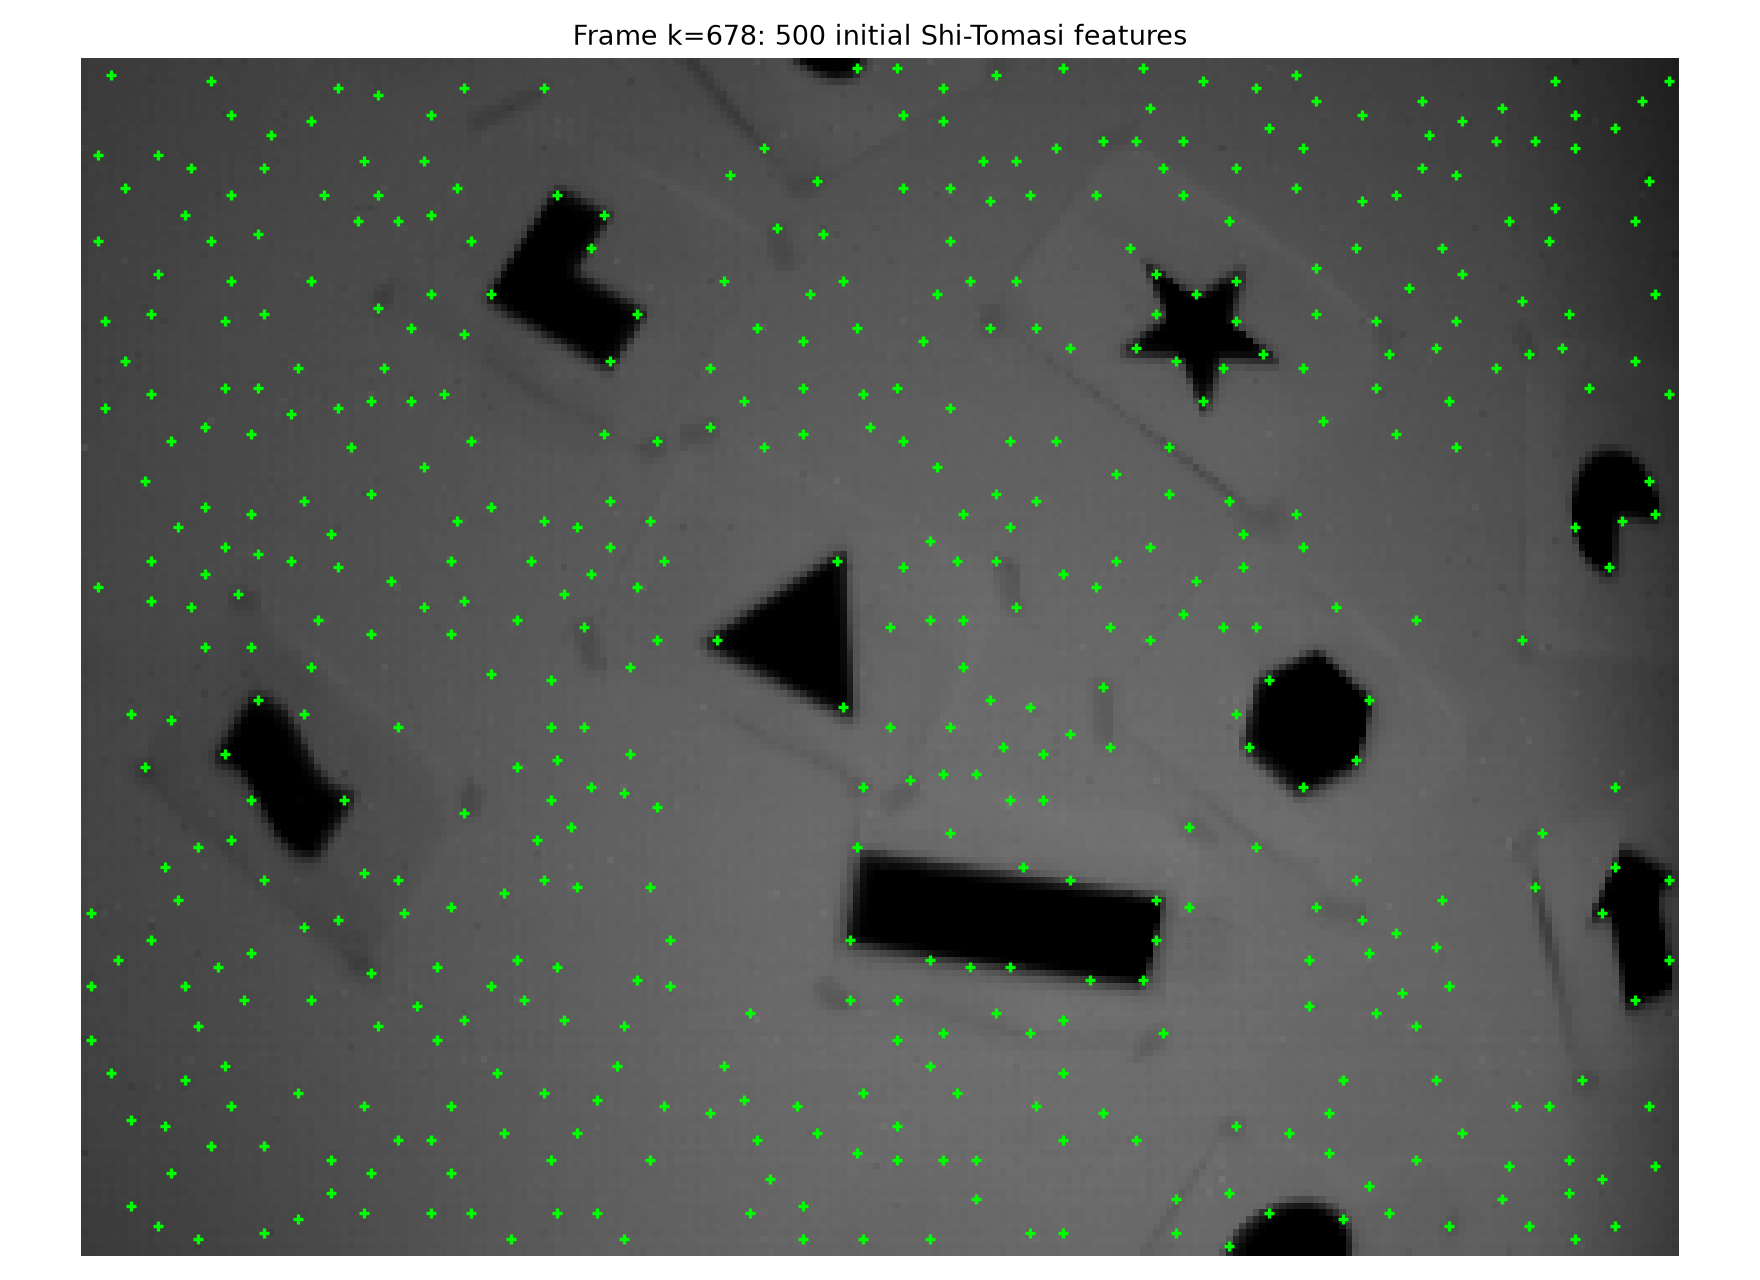

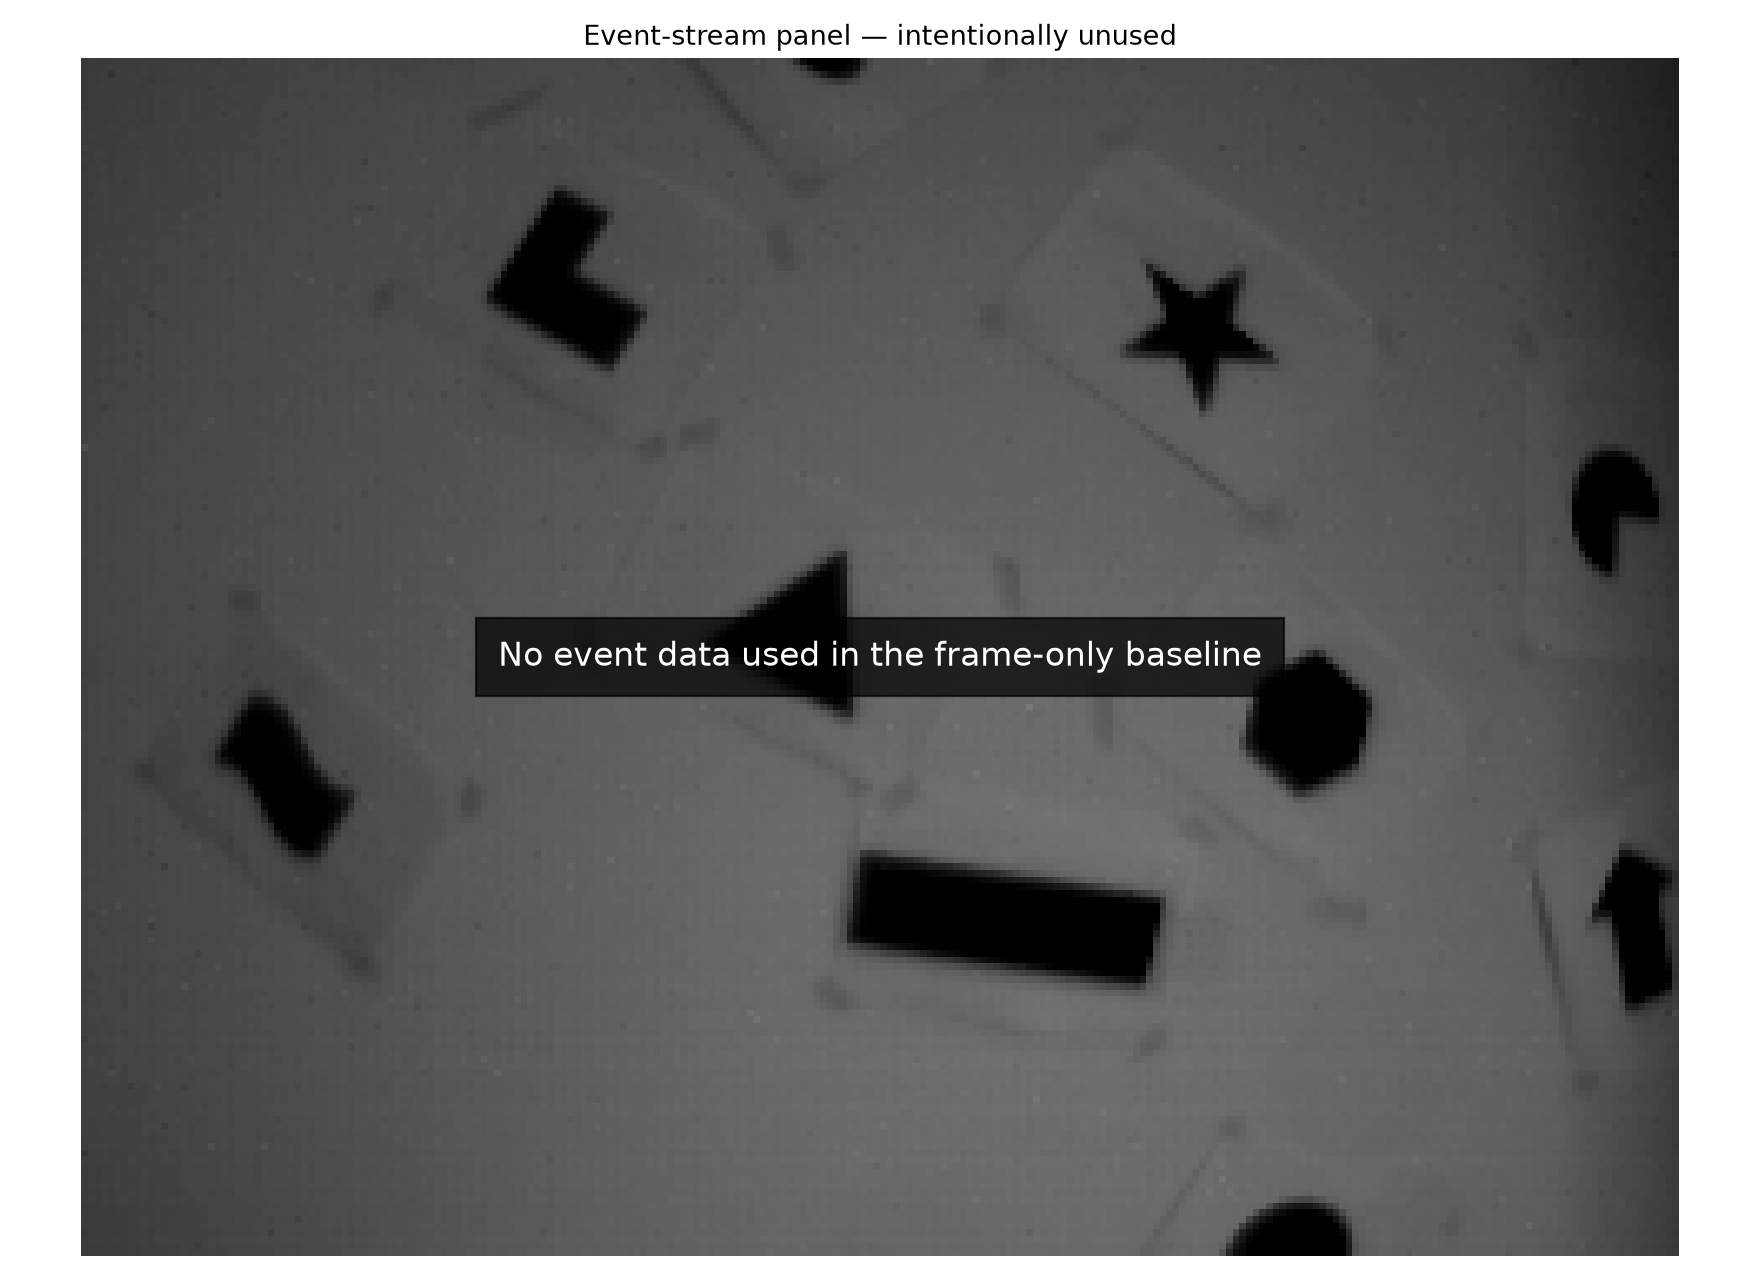

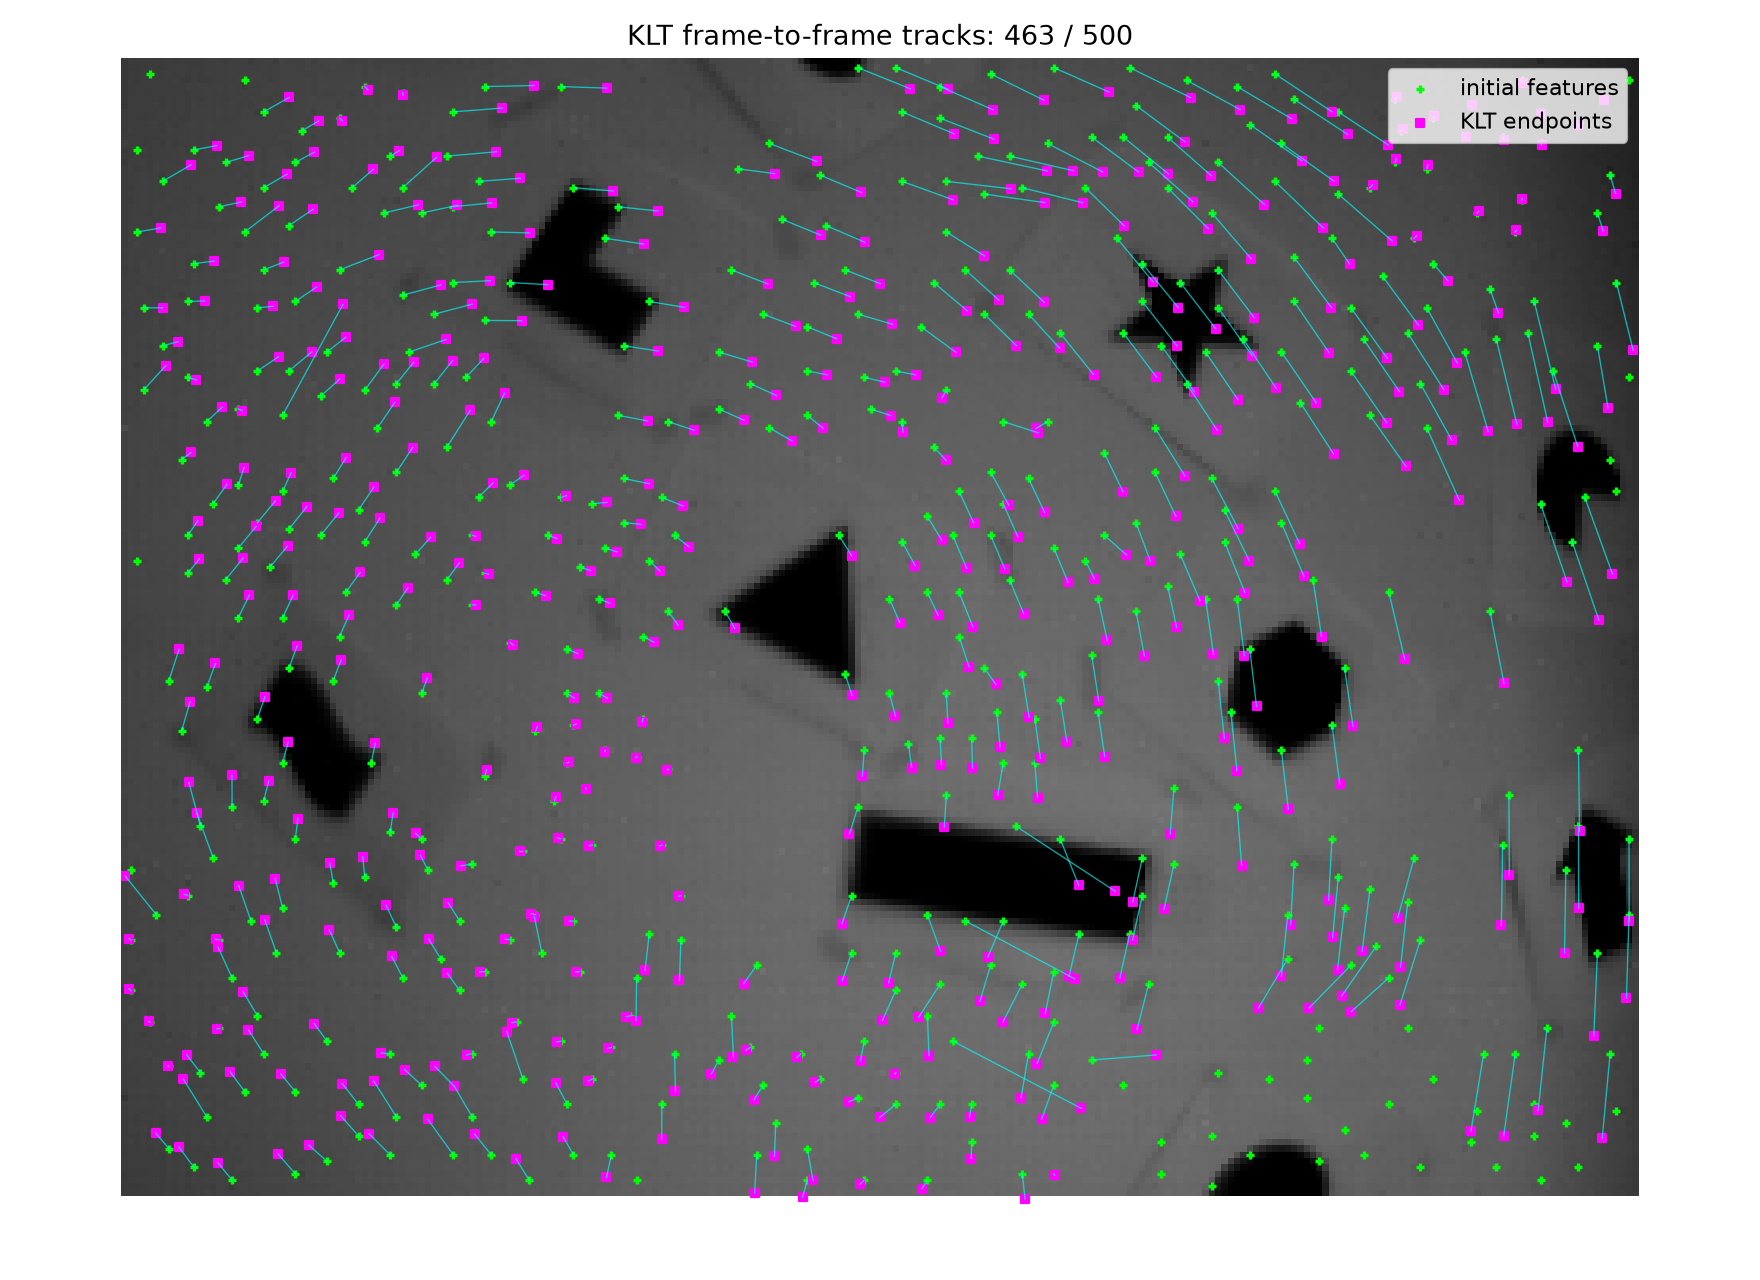

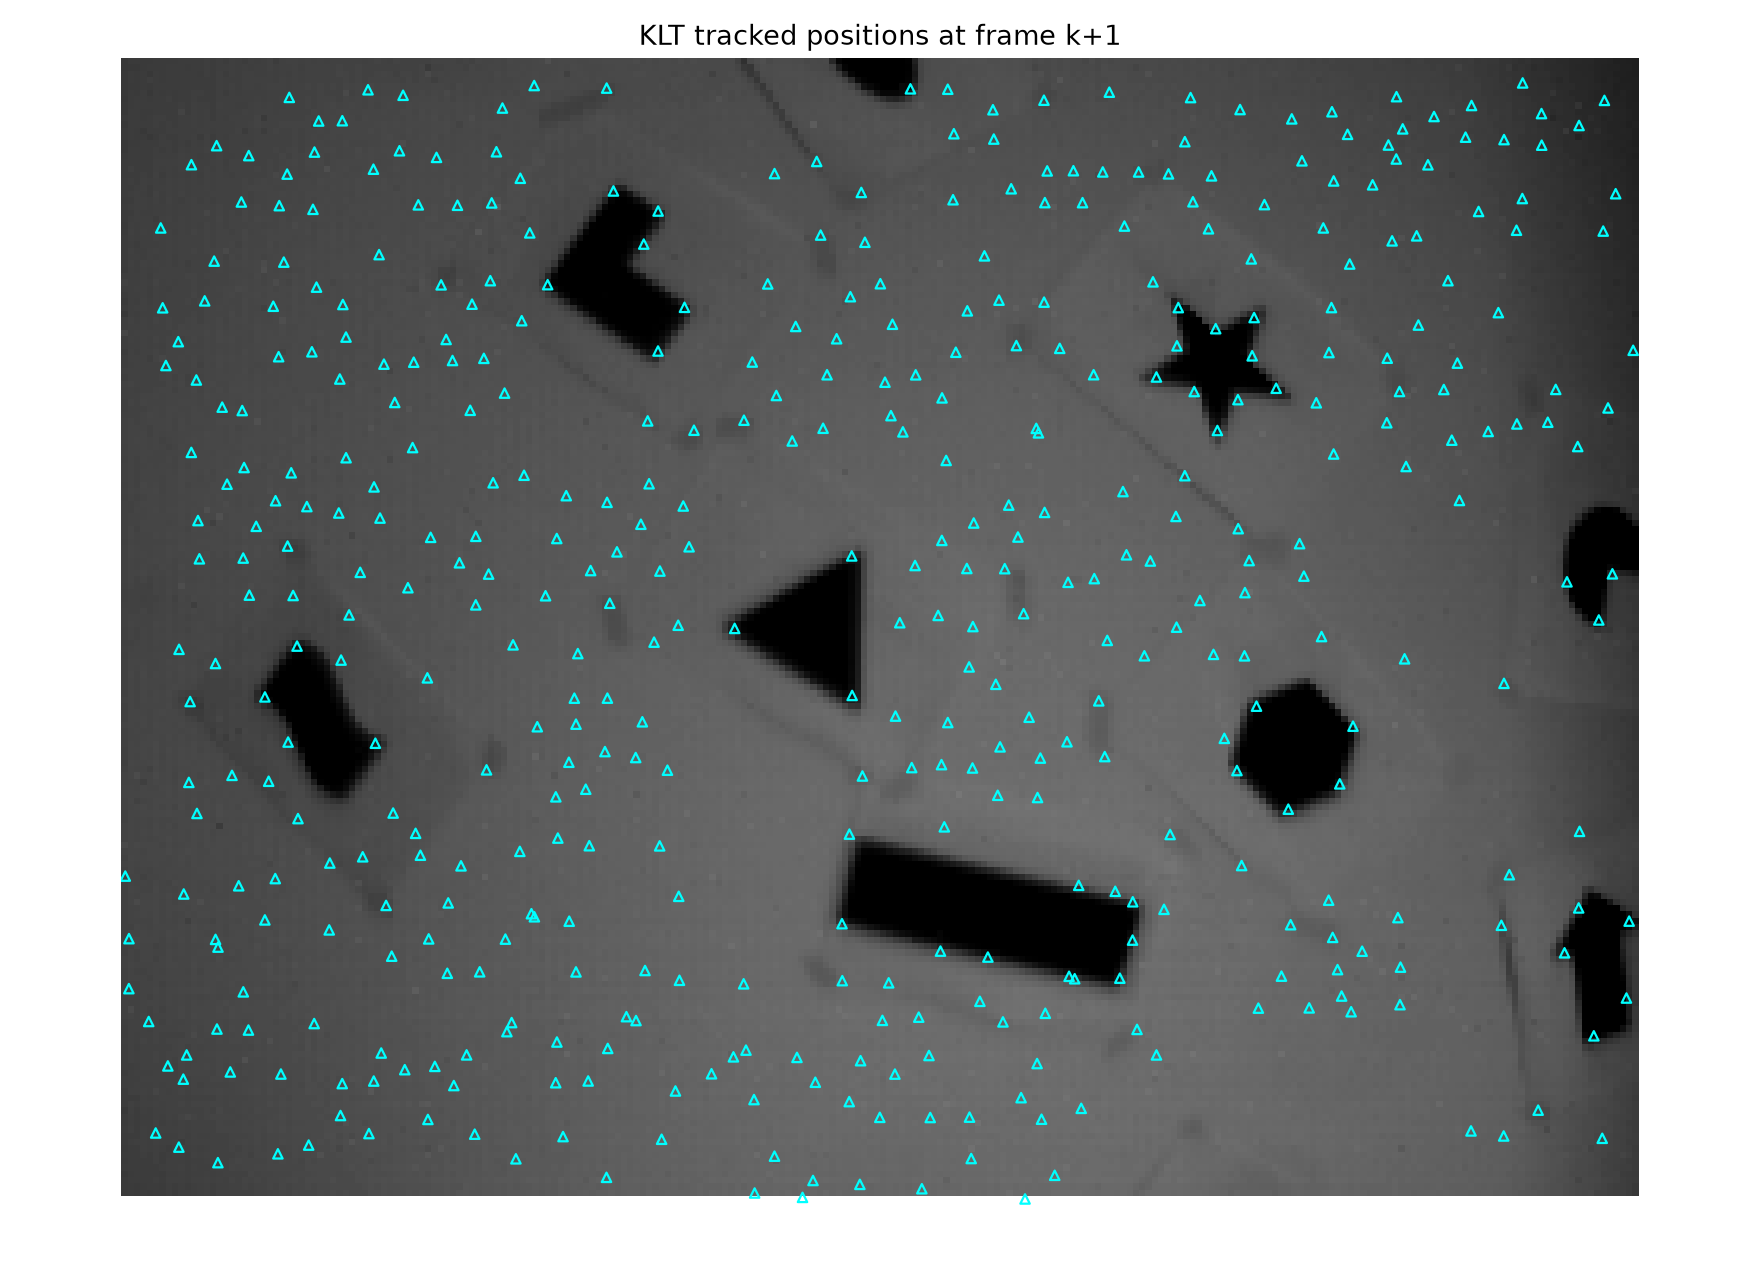

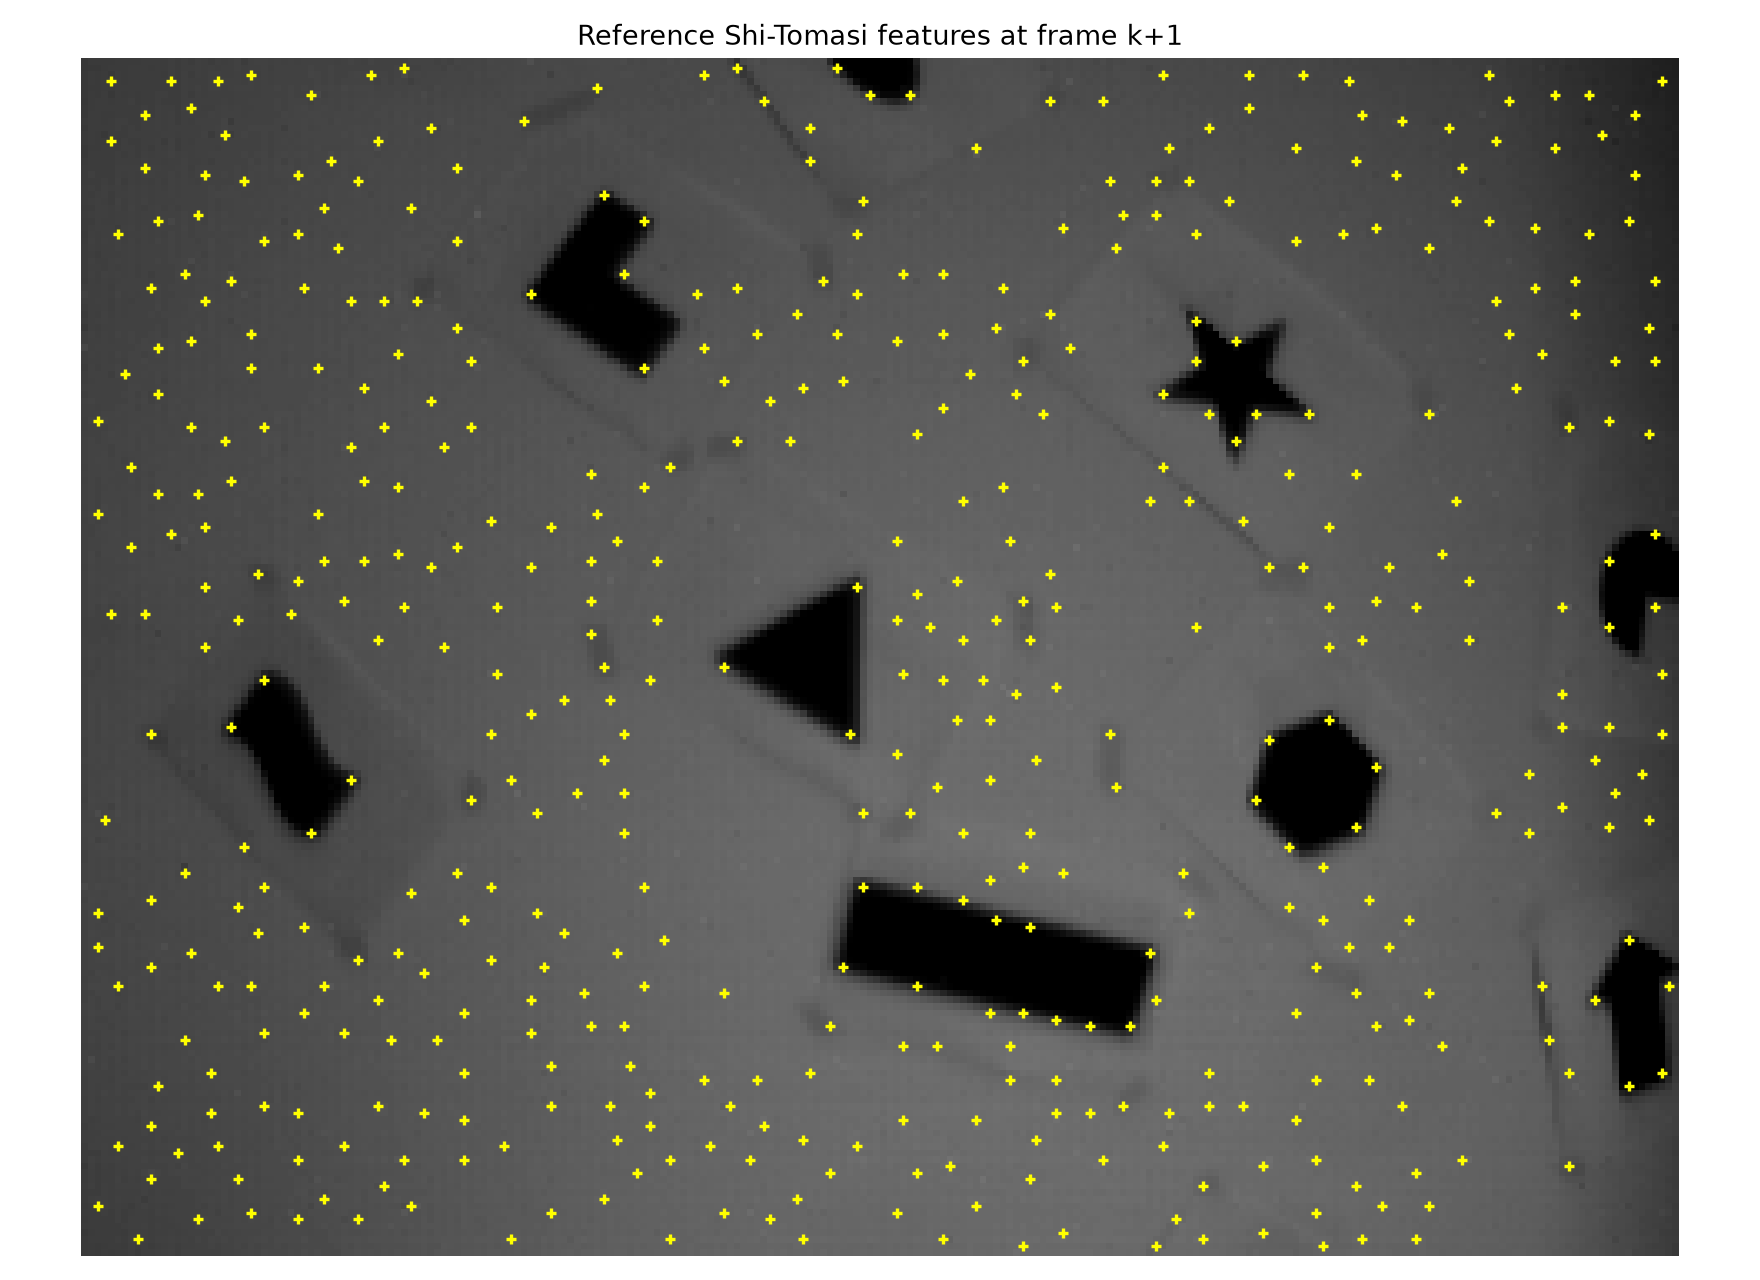

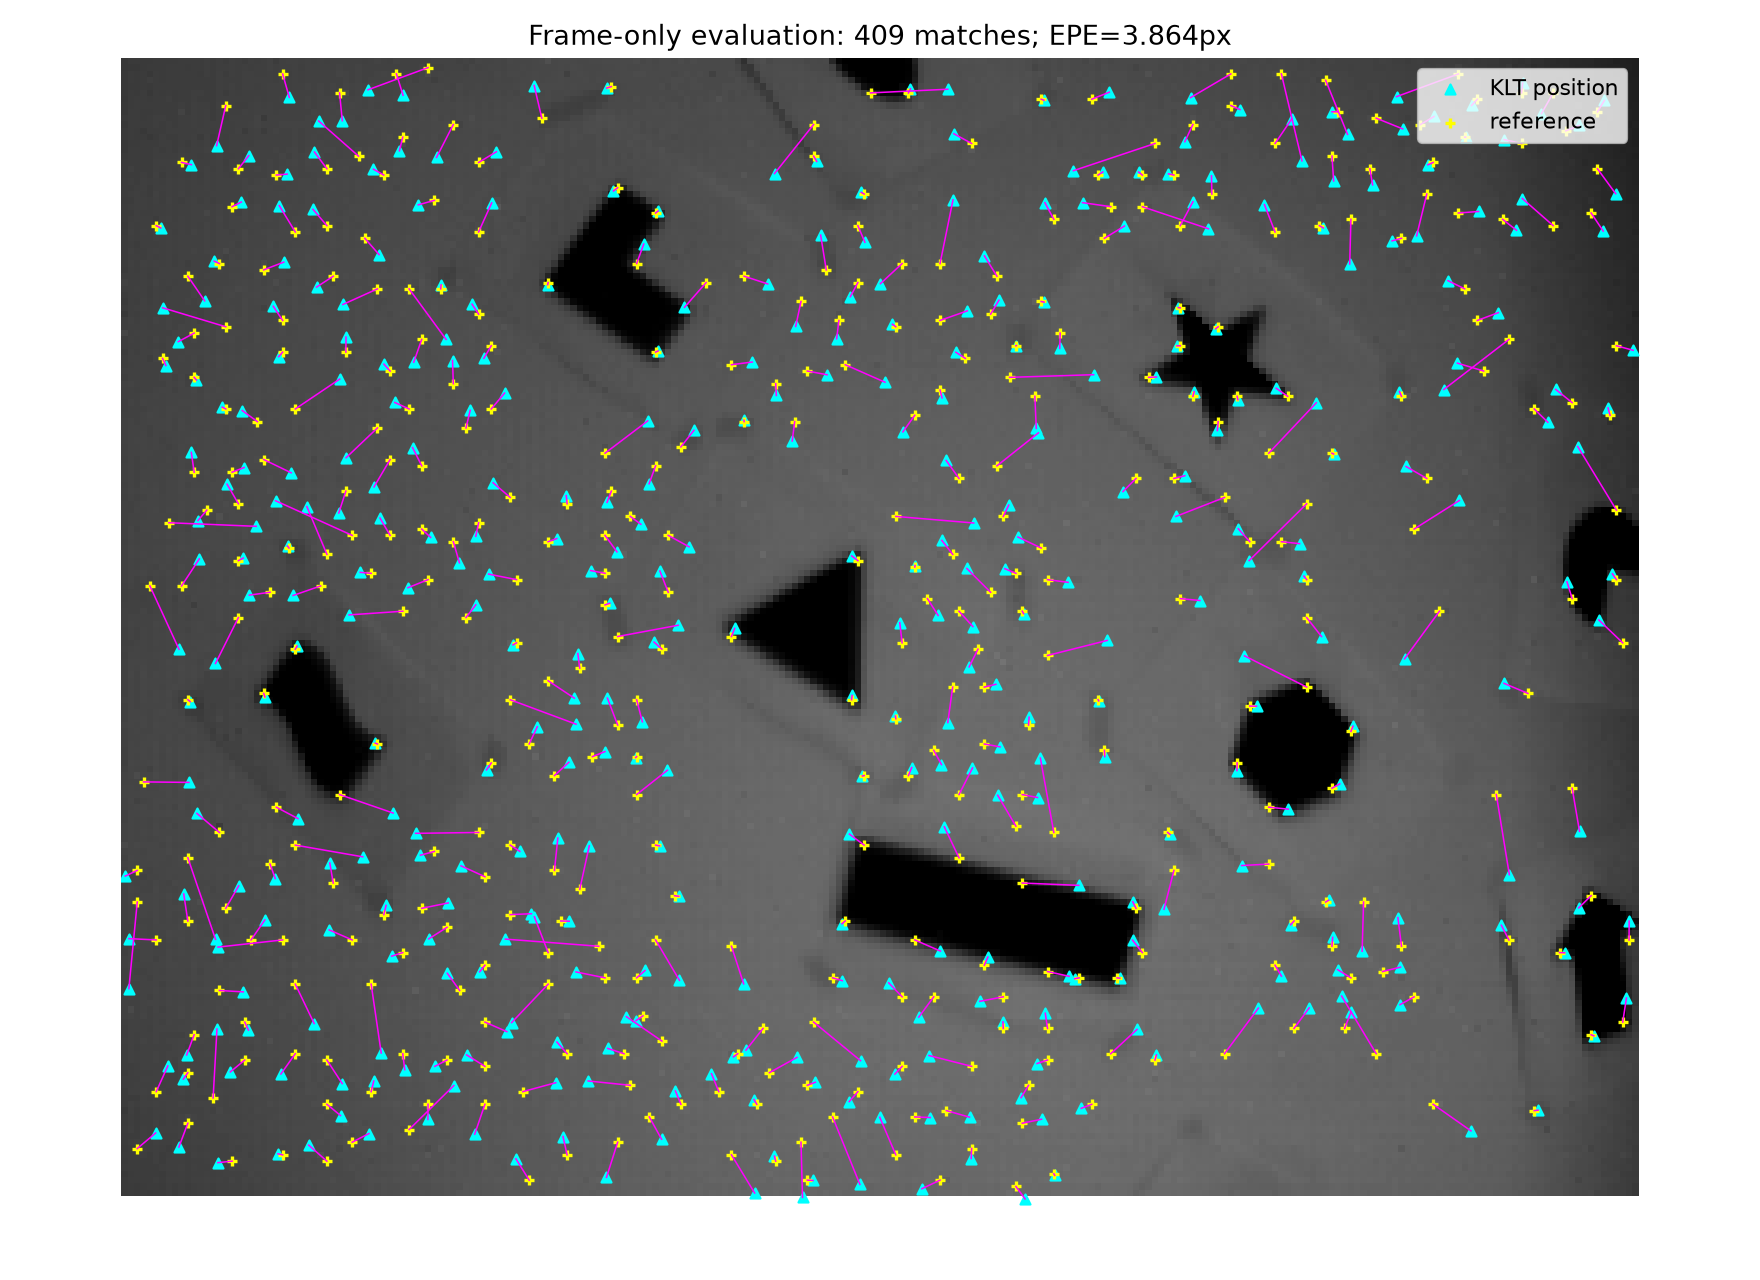

In [3]:
from IPython.display import Image, Markdown, display

display(Markdown(outputs["report"].read_text()))
for name in sorted(key for key in outputs if key.startswith(("01_", "02_", "03_", "04_", "05_", "06_"))):
    display(Image(filename=str(outputs[name])))